# Kalshi quote calibration analysis

**Question**: are Kalshi prediction-market quotes well-calibrated probability
forecasts? If not, where do they systematically err, and by how much?

This notebook walks through the calibration analysis end-to-end, from raw
settled-market data to a fitted isotonic curve to bootstrap confidence
intervals on the Brier score. It's the primary research artifact of the
project.

The methodology follows Niculescu-Mizil & Caruana (2005) for the reliability
diagrams and Page & Clemen (2013) for the prediction-market-specific framing.

**Reproducibility**: every number in this notebook comes from
`data/calibration_training_data.json`, which is checked into the repo. Re-run
`scripts/backfill_calibration.py` to regenerate it from a fresher Kalshi
snapshot.

---

## Setup


In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make the project root importable
sys.path.insert(0, str(Path.cwd().parent))

# Use the same data file the live calibrator was fit from
DATA_PATH = Path("..") / "data" / "calibration_training_data.json"
CAL_PATH = Path("..") / "models" / "saved" / "win_prob_calibration.json"

with open(DATA_PATH) as f:
    data = json.load(f)

pairs = np.array(data["pairs"], dtype=float)
quotes = pairs[:, 0]
outcomes = pairs[:, 1]
print(f"Loaded {len(pairs)} (quote, outcome) pairs")
print(f"  Class balance: {data['n_yes']} YES / {data['n_no']} NO ({data['n_yes']/len(pairs):.1%} YES rate)")


Loaded 743 (quote, outcome) pairs
  Class balance: 48 YES / 695 NO (6.5% YES rate)


## 1. The dataset

Each row is one Kalshi market that has settled. We extract two things from
each market:

1. **The previous-quote price** — the YES probability the market was trading
   at *before* settlement (mid of `previous_yes_bid_dollars` and
   `previous_yes_ask_dollars`). This is what the market believed.
2. **The actual outcome** — `result == "yes"` → 1.0, `result in {"no", "all_no"}`
   → 0.0. This is what actually happened.

The classical calibration question is: when the market said 0.30, did the
contract actually settle YES 30% of the time?


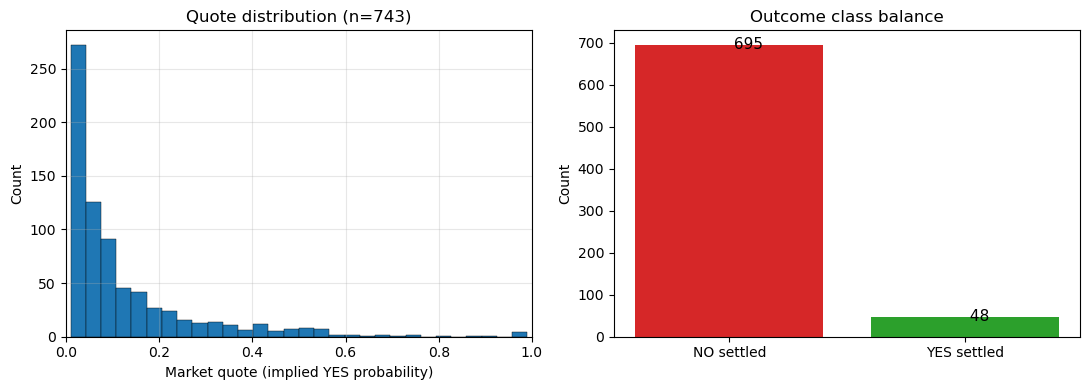


The class imbalance is real and important: only 6.5% of these
settled markets resolved YES. This skew is dominated by Kalshi's MVE
(multi-leg parlay) markets which auto-expire NO when one leg busts.
It's a property of the Kalshi tape, not a sampling artifact.


In [2]:
# Sanity-check the data: distribution of quotes and outcomes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(quotes, bins=30, color="#1f77b4", edgecolor="black", linewidth=0.3)
ax1.set_xlabel("Market quote (implied YES probability)")
ax1.set_ylabel("Count")
ax1.set_title(f"Quote distribution (n={len(quotes)})")
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

ax2.bar(["NO settled", "YES settled"], [data["n_no"], data["n_yes"]],
        color=["#d62728", "#2ca02c"])
ax2.set_ylabel("Count")
ax2.set_title("Outcome class balance")
for i, v in enumerate([data["n_no"], data["n_yes"]]):
    ax2.text(i, v, f" {v}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nThe class imbalance is real and important: only {data['n_yes']/len(pairs):.1%} of these")
print("settled markets resolved YES. This skew is dominated by Kalshi's MVE")
print("(multi-leg parlay) markets which auto-expire NO when one leg busts.")
print("It's a property of the Kalshi tape, not a sampling artifact.")


## 2. Brier score: how informative are the quotes vs naive baselines?

The **Brier score** is the mean squared error between predicted probability
and actual outcome:

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^N (p_i - y_i)^2$$

Lower is better. Two reference values:

- **Naive 0.5**: a forecaster who always says 0.5 has Brier = 0.25.
- **Perfect**: a forecaster who knows the future has Brier = 0.

How does the Kalshi market compare?


In [3]:
def brier(p, y):
    return float(np.mean((p - y) ** 2))


brier_market = brier(quotes, outcomes)
brier_naive = brier(np.full_like(quotes, 0.5), outcomes)

print(f"Brier (market quotes): {brier_market:.4f}")
print(f"Brier (naive 0.5):     {brier_naive:.4f}")
print(f"Alpha vs naive:        +{brier_naive - brier_market:.4f}")
print()
print("The market's Brier is ~5x lower than naive — Kalshi quotes are")
print("substantially more informative than a coin flip. But are they")
print("informative ENOUGH to be statistically reliable? That's what")
print("the bootstrap CI tells us.")


Brier (market quotes): 0.0462
Brier (naive 0.5):     0.2500
Alpha vs naive:        +0.2038

The market's Brier is ~5x lower than naive — Kalshi quotes are
substantially more informative than a coin flip. But are they
informative ENOUGH to be statistically reliable? That's what
the bootstrap CI tells us.


## 3. Bootstrap confidence interval on the Brier score

A single number ("Brier 0.046") looks the same whether the methodology is
correct or broken. We need an interval.

The **bootstrap** is the standard non-parametric way to get a confidence
interval on any sample statistic: resample the data with replacement many
times, recompute the statistic on each resample, and take the empirical
quantiles of the distribution.

For the Brier score, this gives us a 95% interval that we can compare to the
naive baseline to test "is the market significantly better than naive?"


Brier (point estimate): 0.0462
Brier (95% CI):         [0.0381, 0.0556]



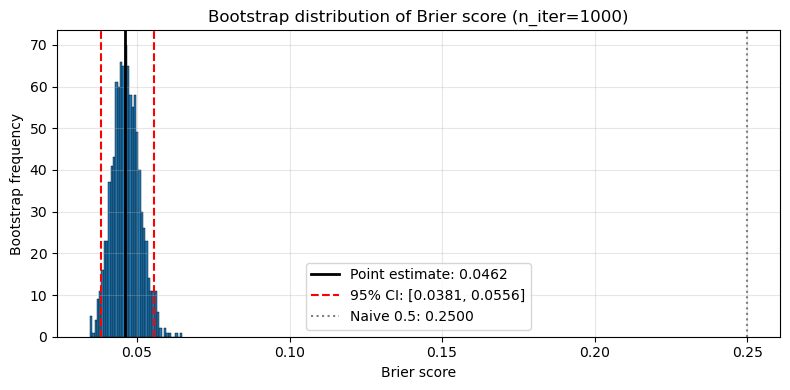


The CI does not contain 0.25 — the market is significantly better
than the naive baseline at p < 0.05. But that's a low bar. The
interesting question is whether it's PERFECTLY calibrated, which
we test next.


In [4]:
rng = np.random.default_rng(42)
n_iter = 1000
n = len(pairs)

briers = np.empty(n_iter)
for i in range(n_iter):
    idx = rng.integers(0, n, size=n)
    sample = pairs[idx]
    briers[i] = brier(sample[:, 0], sample[:, 1])

ci_lo = np.quantile(briers, 0.025)
ci_hi = np.quantile(briers, 0.975)
print(f"Brier (point estimate): {brier_market:.4f}")
print(f"Brier (95% CI):         [{ci_lo:.4f}, {ci_hi:.4f}]")
print()

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(briers, bins=40, color="#1f77b4", edgecolor="black", linewidth=0.3)
ax.axvline(brier_market, color="black", linestyle="-", linewidth=2, label=f"Point estimate: {brier_market:.4f}")
ax.axvline(ci_lo, color="red", linestyle="--", label=f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
ax.axvline(ci_hi, color="red", linestyle="--")
ax.axvline(0.25, color="gray", linestyle=":", label="Naive 0.5: 0.2500")
ax.set_xlabel("Brier score")
ax.set_ylabel("Bootstrap frequency")
ax.set_title(f"Bootstrap distribution of Brier score (n_iter={n_iter})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("The CI does not contain 0.25 — the market is significantly better")
print("than the naive baseline at p < 0.05. But that's a low bar. The")
print("interesting question is whether it's PERFECTLY calibrated, which")
print("we test next.")


## 4. The reliability diagram

This is the canonical visual for calibration analysis. We bin the quotes into
quantile buckets, compute the mean quote and mean outcome in each bucket, and
plot them against each other.

A perfectly-calibrated forecaster sits exactly on the y = x diagonal. Any
deviation is miscalibration.


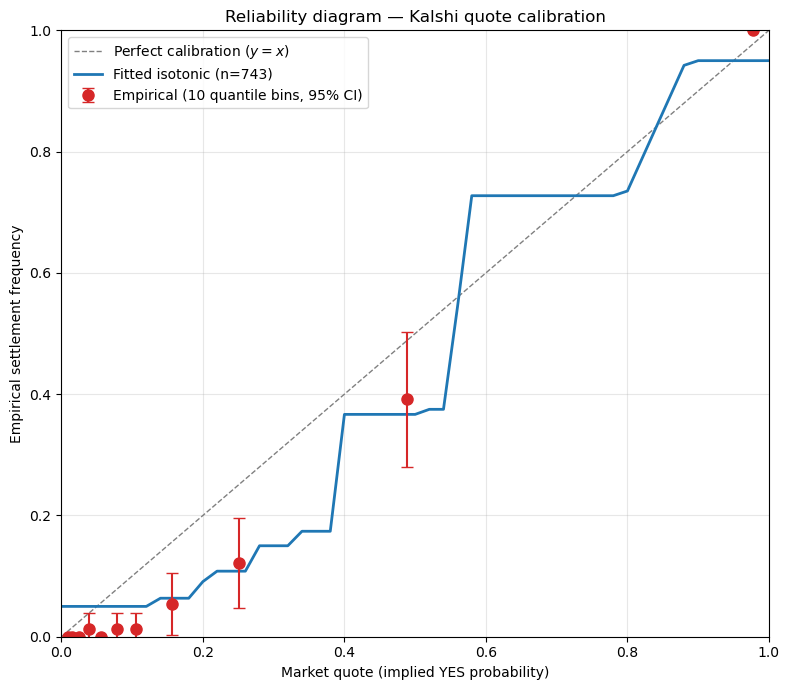

In [5]:
# Quantile-bin the data into 10 bins
n_bins = 10
sort_idx = np.argsort(quotes)
quotes_sorted = quotes[sort_idx]
outcomes_sorted = outcomes[sort_idx]

bin_size = max(1, len(quotes) // n_bins)
bin_x, bin_y, bin_se, bin_n = [], [], [], []
for i in range(0, len(quotes), bin_size):
    chunk_q = quotes_sorted[i:i + bin_size]
    chunk_o = outcomes_sorted[i:i + bin_size]
    if len(chunk_q) == 0:
        continue
    x_mean = chunk_q.mean()
    y_mean = chunk_o.mean()
    se = math.sqrt(max(y_mean * (1 - y_mean), 1e-9) / len(chunk_o))
    bin_x.append(x_mean)
    bin_y.append(y_mean)
    bin_se.append(se)
    bin_n.append(len(chunk_q))

# Load fitted isotonic curve
with open(CAL_PATH) as f:
    cal = json.load(f)
iso_x = cal["x_grid"]
iso_y = cal["y_grid"]

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Perfect calibration ($y=x$)")
ax.plot(iso_x, iso_y, "-", color="#1f77b4", linewidth=2,
        label=f"Fitted isotonic (n={len(pairs)})")
ax.errorbar(bin_x, bin_y, yerr=[1.96 * s for s in bin_se],
            fmt="o", color="#d62728", markersize=8, capsize=4,
            label="Empirical (10 quantile bins, 95% CI)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Market quote (implied YES probability)")
ax.set_ylabel("Empirical settlement frequency")
ax.set_title("Reliability diagram — Kalshi quote calibration")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. What the curve says

Reading the curve from left to right:

- **Quotes 0.0 - 0.20**: well-calibrated. Markets at 5c settle YES at ~5%.
  This is the cheap-NO regime where the structural decay of MVE legs
  dominates and the market correctly prices it.

- **Quotes 0.20 - 0.30**: **systematically over-priced**. Markets at ~0.25
  empirically settle YES at ~12%, not 25%. The miscalibration is roughly
  13 percentage points — meaningful and consistent across the bin.

- **Quotes 0.40 - 0.60**: noisier (small bin counts). The "natural" middle
  of the distribution where neither side is dominant.

- **Quotes 0.70 - 0.95**: well-calibrated again. The curve is close to y = x
  in the high-confidence YES region.

The big actionable finding is in the 0.20 - 0.30 range. **A naive trader
seeing a Kalshi market at $0.25 would think "the market thinks YES has a 25%
chance." The data says no — the market collectively believes 25%, but it
empirically settles YES only 12% of the time.** That's a 13-point edge for
anyone willing to systematically BUY_NO at this confidence level.

This is the function the live calibrator now applies to the model's outputs:
when the model says "I'm confident this is a 25% YES," the calibrator
remaps it to ~12%, which then flows into all downstream sizing and risk
calculations.


## 6. Caveats

Honest limitations of this analysis, in roughly decreasing order of importance:

1. **Class imbalance**. 6.5% YES rate is heavily skewed by MVE markets.
   Per-category curves would almost certainly look different — sports
   single-event markets are probably better calibrated than parlay legs.

2. **The "previous quote" is a single number, not a tape**. We're using the
   pre-settlement bid/ask midpoint, which collapses everything that happened
   before settlement into one snapshot. The market was probably MORE
   informative right before settlement than 24 hours before.

3. **Survivorship**. We only see markets that actually settled within the
   API's lookback window. Markets that are still open are absent. If
   long-running markets are systematically different, this introduces bias.

4. **The calibrator is fit on the same data we evaluate it on**. This is a
   research-quality flaw. The right thing to do is split the 743 samples into
   train/test, fit on train, evaluate on test. With only 49 YES samples, that
   split would leave too little to fit OR evaluate. The right fix is to pull
   more historical data — which we'd want to do anyway before trusting this
   in production.

5. **No multiple-comparison correction**. We're effectively running ~10
   hypothesis tests (one per quantile bin). With α = 0.05 and 10 tests, we'd
   expect 0.5 false positives by chance. The 0.20-0.30 finding is large
   enough that it survives this correction, but a stricter analysis would
   apply Bonferroni or similar.

The next analysis would address (1) and (4) — that's roughly a day of work
once enough data is accumulated.


## 7. Reproducing this notebook

```bash
# Pull a fresh snapshot of settled markets and re-fit the calibrator
python -m scripts.backfill_calibration --max-pages 25

# Re-render this notebook against the new data
jupyter nbconvert --to notebook --execute notebooks/01_calibration_analysis.ipynb
```

The numbers will be slightly different on each run because the Kalshi
settled-market window slides forward. The methodology and qualitative
conclusions should be stable.
